In [32]:
import os
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

path = '/home/mina-joojoo/Desktop/tool_wearing/'
dataset = pd.read_csv(path + 'correlated_dataset.csv')
dataset = pd.get_dummies(dataset, columns=["machine"], dtype=int)
dataset.columns

Index(['VB', 'tool', 'C', 'torque_x_mean', 'torque_x_max', 'torque_x_min',
       'torque_x_rms', 'torque_y_mean', 'torque_y_max', 'torque_y_min',
       'torque_y_rms', 'torque_z_std', 'torque_z_min', 'f_sens_mean',
       'f_sens_max', 'f_sens_min', 'f_sens_rms', 'fx_sens_mean', 'fx_sens_rms',
       'fx_sens_skew', 'fy_sens_mean', 'fy_sens_max', 'fy_sens_rms',
       'fz_sens_mean', 'fx_mean', 'fx_rms', 'fy_max', 'machine_1.0',
       'machine_2.0', 'machine_3.0'],
      dtype='object')

In [49]:
dataset = dataset.dropna(axis=1, how='all')
dataset.shape

(6418, 30)

Epoch 1/30


/home/mina-joojoo/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


159/159 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - loss: 0.0075 - val_loss: 0.0179
Epoch 2/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.0031 - val_loss: 0.0057
Epoch 3/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0027 - val_loss: 0.0062
Epoch 4/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0022 - val_loss: 0.0033
Epoch 5/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0020 - val_loss: 0.0039
Epoch 6/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - loss: 0.0023 - val_loss: 0.0063
Epoch 7/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.0019 - val_loss: 0.0038
Epoch 8/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 9/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.0021 - val_loss: 0.0182
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


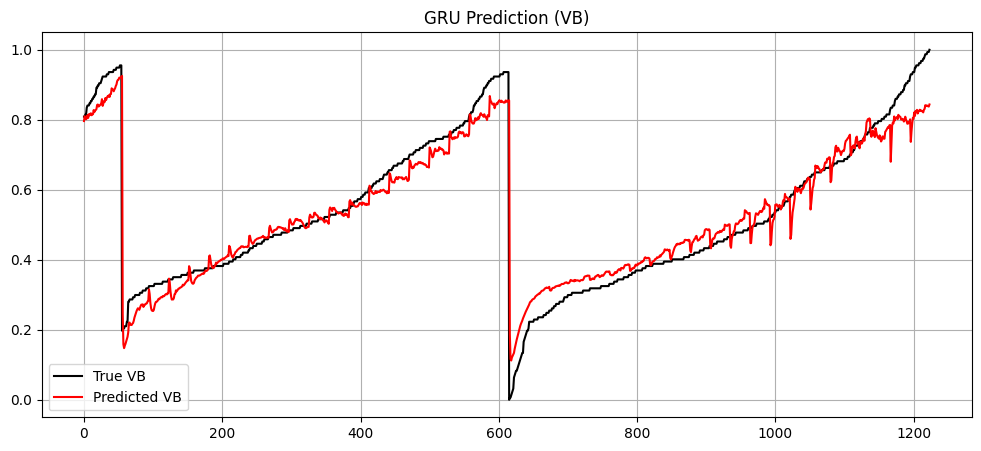

In [58]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping


# ===============================
# 2. LOAD & PREPARE DATA
# ===============================
path = '/home/mina-joojoo/Desktop/tool_wearing/'
dataset = pd.read_csv(path + 'correlated_dataset.csv')

# one-hot encode machine
dataset = pd.get_dummies(dataset, columns=["machine"], dtype=int)

# remove NaN columns (you already ensured dataset is clean)
dataset = dataset.dropna(axis=1, how='any')

# reset index (IMPORTANT)
data = dataset.reset_index(drop=True)

# -------------------------------
# FEATURES / TARGET
# -------------------------------
X = data.drop(columns=["VB"]).values
y = data["VB"].values.reshape(-1, 1)


# ===============================
# 3. TRAIN / TEST SPLIT (TIME-BASED ✅)
# ===============================
split = int(0.8 * len(data))

X_train_raw = X[:split]
X_test_raw  = X[split:]

y_train_raw = y[:split]
y_test_raw  = y[split:]


# ===============================
# 4. SCALING (CRUCIAL)
# ===============================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_test_scaled  = scaler_y.transform(y_test_raw)


# ===============================
# 5. CREATE SEQUENCES
# ===============================
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []

    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])

    return np.array(X_seq), np.array(y_seq)


SEQ_LEN = 60   # important: long enough for slow trend

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test_scaled,  SEQ_LEN)


# ===============================
# 6. BUILD GRU MODEL
# ===============================
n_features = X_train_seq.shape[2]

model = Sequential([
    GRU(128, return_sequences=True, input_shape=(SEQ_LEN, n_features)),
    GRU(64),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)


# ===============================
# 7. TRAIN
# ===============================
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=[early_stop],
    verbose=1
)


# ===============================
# 8. PREDICT
# ===============================
y_pred_scaled = model.predict(X_test_seq)

# inverse scaling
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_seq)


# ===============================
# 9. PLOT (CORRECTLY ALIGNED ✅)
# ===============================
plt.figure(figsize=(12,5))

# true values
plt.plot(y_true, label="True VB", color="black")

# predicted values
plt.plot(y_pred, label="Predicted VB", color="red")

plt.title("GRU Prediction (VB)")
plt.legend()
plt.grid()

plt.show()


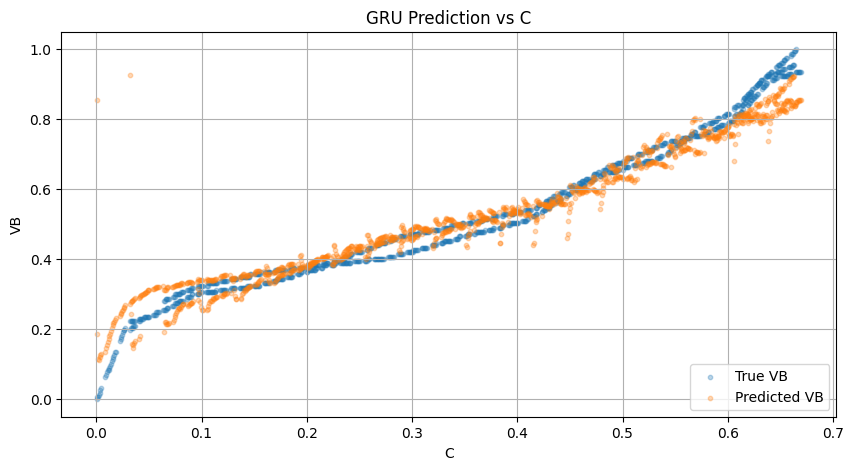

In [60]:
# flatten everything
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# corresponding x-axis from test set (C)
C_test = X_test_raw[:, list(data.drop(columns=["VB"]).columns).index("C")]

# align with sequences
C_test_aligned = C_test[SEQ_LEN:]

# sort by C
sorted_idx = np.argsort(C_test_aligned)

C_sorted = C_test_aligned[sorted_idx]
y_true_sorted = y_true_flat[sorted_idx]
y_pred_sorted = y_pred_flat[sorted_idx]

# plot
plt.figure(figsize=(10,5))

plt.scatter(C_sorted, y_true_sorted, s=10, alpha=0.3, label="True VB")
plt.scatter(C_sorted, y_pred_sorted, s=10, alpha=0.3, label="Predicted VB")

plt.xlabel("C")
plt.ylabel("VB")
plt.title("GRU Prediction vs C")

plt.legend()
plt.grid()
plt.show()

In [63]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true, y_pred)

print("Test MSE:", mse)

Test MSE: 0.003225866489155279


Text(0.5, 1.0, 'MSE: 0.003')

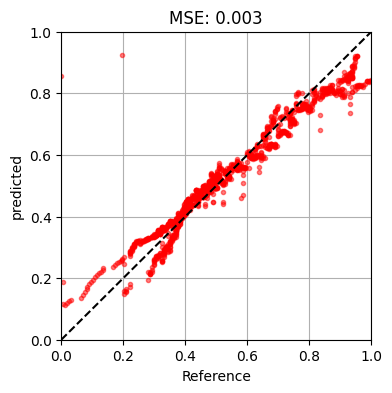

In [66]:
plt.figure(figsize = (4,4))
plt.plot(y_true, y_pred, '.r', alpha=0.5)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Reference')
plt.ylabel('predicted')
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid()
plt.title(f'MSE: {mse:.3f}')
